In [1]:
from pathlib import Path
import torch

from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.utils import create_graph_files

model_name = "qwen3-4b"
transcoder_name = "mwhanna/qwen3-4b-transcoders"
backend = 'transformerlens'  # change to 'nnsight' for the nnsight backend!
model = ReplacementModel.from_pretrained(
    model_name, transcoder_name, dtype=torch.bfloat16, lazy_encoder=True, backend=backend
)

Fetching 36 files:   0%|          | 0/36 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model qwen3-4b into HookedTransformer


In [3]:
from attribute_utils import format_qwen

messages = [
    {"role": "system", "content": "Answer the question in one word and no more."},
    {"role": "user", "content": "abuja is to nigeria as amman is to?"},
]

prompt = format_qwen(messages, add_generation_prompt=True, enable_thinking=False)

max_n_logits = 10
desired_logit_prob = 0.95
max_feature_nodes = 8192
batch_size = 256
offload = "cpu"
verbose = True

In [4]:
graph = attribute(
    prompt=prompt,
    model=model,
    max_n_logits=max_n_logits,
    desired_logit_prob=desired_logit_prob,
    batch_size=batch_size,
    max_feature_nodes=max_feature_nodes,
    offload=offload,
    verbose=verbose,
)

Phase 0: Precomputing activations and vectors
Precomputation completed in 11.90s
Found 64704 active features
Phase 1: Running forward pass
Forward pass completed in 0.65s
Phase 2: Building input vectors
Using 1 salient logits with cumulative probability 0.9570
Will include 8192 of 64704 feature nodes
Input vectors built in 1.92s
Phase 3: Computing logit attributions
<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Logit attributions completed in 0.84s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:13<00:00, 586.78it/s]
Feature attributions completed in 13.96s
Attribution completed in 34.11s


In [5]:
graph_dir = "graphs/qwen3-4b"
graph_name = "analogies_0.pt"
graph_dir = Path(graph_dir)
# create intermediate parent directories if needed
graph_dir.mkdir(parents=True, exist_ok=True)
graph_path = graph_dir / graph_name

graph.to_pt(graph_path)

In [6]:
import torch
import matplotlib.pyplot as plt
from circuit_tracer.graph import Graph, normalize_matrix, compute_influence


def plot_influence_per_layer(graph: Graph):
    print(graph.adjacency_matrix.shape)
    n_logits = len(graph.logit_targets)
    n_tokens = len(graph.input_tokens)
    n_features = len(graph.selected_features)
    n_layers = graph.cfg.n_layers

    error_start = n_features
    error_end = error_start + n_layers * n_tokens

    logit_weights = torch.zeros(
        graph.adjacency_matrix.shape[0], device=graph.adjacency_matrix.device
    )
    logit_weights[-n_logits:] = graph.logit_probabilities

    node_influence = compute_influence(normalize_matrix(graph.adjacency_matrix), logit_weights)

    # Error influence per layer: errors are laid out as error[layer][pos]
    error_infl = node_influence[error_start:error_end].reshape(n_layers, n_tokens)
    error_per_layer = error_infl.sum(dim=-1).cpu()

    # Feature influence per layer: look up each selected feature's layer
    feature_layers = graph.active_features[graph.selected_features][:, 0]  # (n_features,)
    feature_infl = node_influence[:n_features].cpu()
    feature_per_layer = torch.zeros(n_layers)
    feature_per_layer.scatter_add_(0, feature_layers.cpu().long(), feature_infl)

    total_per_layer = feature_per_layer + error_per_layer

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    x = range(n_layers)

    axes[0].bar(x, error_per_layer.numpy())
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Influence")
    axes[0].set_title("Error-node influence per layer")

    axes[1].bar(x, feature_per_layer.numpy(), label="features")
    axes[1].bar(x, error_per_layer.numpy(), bottom=feature_per_layer.numpy(), label="errors")
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("Influence")
    axes[1].set_title("Total influence per layer (features + errors)")
    axes[1].legend()

    plt.tight_layout()
    return fig, {"error": error_per_layer, "feature": feature_per_layer, "total": total_per_layer}


torch.Size([9193, 9193])


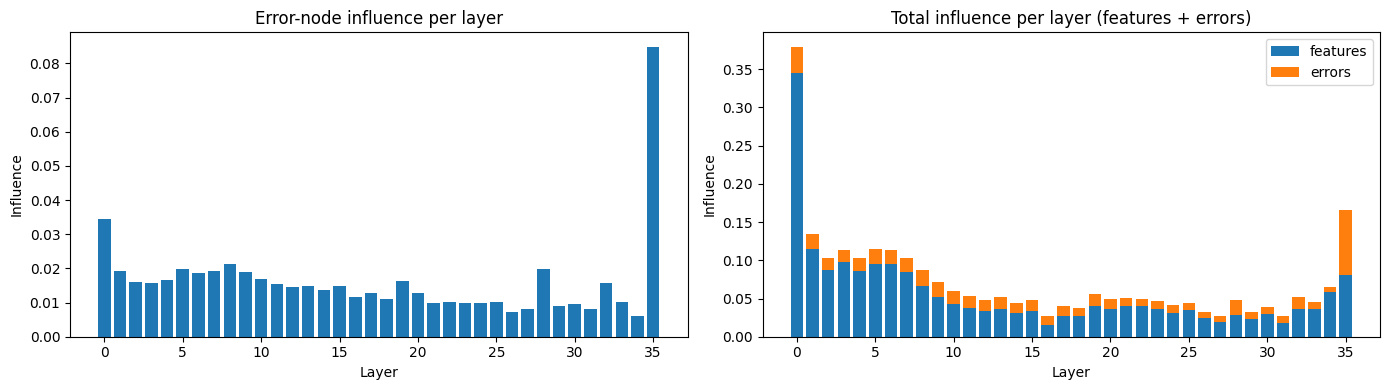

In [7]:
from circuit_tracer import Graph
g = Graph.from_pt("graphs/qwen3-4b/analogies_0.pt")
ax, per_layer = plot_influence_per_layer(g)
plt.show()

In [6]:
from circuit_tracer.utils.create_graph_files import create_graph_files_from_prune_graph, create_graph_files

slug = "analogies_0"  # this is the name that you assign to the graph
graph_file_dir = "./graph_files"  # where to write the graph files. no need to make this one; create_graph_files does that for you
node_threshold = 0.7  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
edge_threshold = 0.95  # keep only the minimum # of edges whose cumulative influence is >= 0.98

create_graph_files(
    graph_or_path=graph_path,  # the graph to create files for
    slug=slug,
    output_path=graph_file_dir,
    node_threshold=node_threshold,
    edge_threshold=edge_threshold,
)
# create_graph_files_from_prune_graph(pg, slug="example", output_path="graphs/example_graph.json")

In [7]:
from circuit_tracer.frontend.local_server import serve


port = 8046
server = serve(data_dir="graphs_files/", port=port)

from IPython.display import IFrame

print(f"Use the IFrame below, or open your graph here: f'http://localhost:{port}/index.html'")
display(IFrame(src=f"http://localhost:{port}/index.html", width="100%", height="800px"))

Use the IFrame below, or open your graph here: f'http://localhost:8046/index.html'


In [6]:
server.stop()

In [1]:
from summarization.prune import prune_pt_graph
from summarization.cluster import cluster_graph_spectral, clusters_to_supernodes
from summarization.cluster_viz import supernode_graph_figure
from summarization.summarize import SummaryGraph

graph_path = "graphs/qwen3-4b/analogies_0.pt"
prune_graph = prune_pt_graph(graph_path, node_threshold=0.01, edge_threshold=0.95)
clusters = cluster_graph_spectral(prune_graph, target_k=7, mean_method = "geo", enforce_dag = True)
rows = clusters_to_supernodes(prune_graph, clusters)
supernode_map = {s.name: s.member_node_ids() for s in rows}
sng = SummaryGraph(supernodes=rows, pruned_adj=prune_graph.pruned_adj)
# supernode_graph_figure(sng, supernode_map)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'SN_0 -> SN_EMB_0<br>weight=-0.1234<extra></extra>',
              'line': {'color': 'rgba(203,24,29,0.151)', 'width': 0.5080412961519495},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 0.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_1<br>weight=0.0375<extra></extra>',
              'line': {'color': 'rgba(33,120,78,0.150)', 'width': 0.5024423150342809},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 1.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_2<br>weight=-0.1541<extra></extra>',
              'line': {'color': 'rgba(203,24,29,0.151)', 'width': 0.5100377010324038},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 12.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_3<br>weight=0.0828<extra></extra>',
              'line': {'color': 'rgba(33,120,78,0.150)', 'width': 0.5053926793185181},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 23.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_4<br>weight=-0.1543<extra></extra>',
              'line': {'color': 'rgba(203,24,29,0.151)', 'width': 0.510053608641013},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 32.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_5<br>weight=0.0947<extra></extra>',
              'line': {'color': 'rgba(33,120,78,0.151)', 'width': 0.5061721521403687},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 33.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_6<br>weight=-0.0670<extra></extra>',
              'line': {'color': 'rgba(203,24,29,0.150)', 'width': 0.504368627014301},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 34.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_7<br>weight=0.0559<extra></extra>',
              'line': {'color': 'rgba(33,120,78,0.150)', 'width': 0.5036428423715062},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 35.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_8<br>weight=-0.1519<extra></extra>',
              'line': {'color': 'rgba(203,24,29,0.151)', 'width': 0.509894532554921},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 36.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_9<br>weight=-0.1326<extra></extra>',
              'line': {'color': 'rgba(203,24,29,0.151)', 'width': 0.5086378314747944},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 37.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_10<br>weight=-0.0208<extra></extra>',
              'line': {'color': 'rgba(203,24,29,0.150)', 'width': 0.5013521467317819},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 2.0],
              'y': [1.0, 0.0]},
             {'hovertemplate': 'SN_0 -> SN_EMB_11<br>weight=0.0550<extra></extra>',
              'line': {'color': 'rgba(33,120,78,0.150)', 'width': 0.5035831888392218},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0, 3.0],
              'y': [1.0, 

In [2]:
print(clusters)

[['30_154434_37', '31_10325_37'], ['33_82035_37', '34_28807_37', '34_83281_37'], ['33_133276_37'], ['34_27255_37'], ['34_75679_37', '34_148285_37', '35_69423_37'], ['35_10607_37', '35_135395_37'], ['35_23398_37', '35_48496_37', '35_103761_37', '35_125398_37', '35_132280_37'], ['E_151644_0'], ['E_8948_1'], ['E_198_2'], ['E_16141_3'], ['E_279_4'], ['E_3405_5'], ['E_304_6'], ['E_825_7'], ['E_3409_8'], ['E_323_9'], ['E_902_10'], ['E_803_11'], ['E_13_12'], ['E_151645_13'], ['E_198_14'], ['E_151644_15'], ['E_872_16'], ['E_198_17'], ['E_370_18'], ['E_88708_19'], ['E_374_20'], ['E_311_21'], ['E_90977_22'], ['E_438_23'], ['E_1079_24'], ['E_1515_25'], ['E_374_26'], ['E_311_27'], ['E_30_28'], ['E_151645_29'], ['E_198_30'], ['E_151644_31'], ['E_77091_32'], ['E_198_33'], ['E_151667_34'], ['E_271_35'], ['E_151668_36'], ['E_271_37'], ['37_70424_0']]
